# Unsupervised Learning –Clustering
    1) K-means,K-means++
    2) Hierarchical Method


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
def plot_scatter(X,  color='k', alpha=0.6):
    #if use color index , the index must be between 0 and 1    
    return plt.scatter(X[:, 0],
                       X[:, 1],
                       c=color,
                       alpha=alpha,
                       edgecolor='k')    


## Genearte sample data and visualiztion

In [3]:
n1=5
n2=5
# cluster 
x1 = np.random.normal(60,10, n1)  # np.random.normal(mu,sigma,size))
y1 = np.random.normal(5, 0.5,n1)
C1=np.array(list(zip(x1,y1)))
# cluster 
x2 = np.random.normal(30,10,n2)
y2 = np.random.normal(5,0.5,n2)
C2=np.array(list(zip(x2,y2)))

X_train = np.concatenate((C1,C2))

print(np.mean(C1,axis=0))
print(np.mean(C2,axis=0))

[64.8520615  5.1212409]
[28.77876221  4.8261121 ]


In [4]:
X_train 

array([[72.23866396,  6.06099661],
       [60.99660317,  4.70995394],
       [60.97957342,  5.00212012],
       [73.92044753,  5.28836022],
       [56.12501941,  4.54477361],
       [24.51904689,  4.50572225],
       [29.97504101,  4.97536821],
       [27.29139912,  5.59020907],
       [17.02036293,  4.56046145],
       [45.08796113,  4.49879951]])

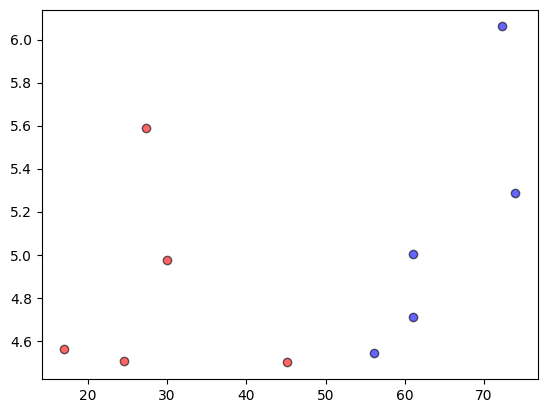

In [5]:
plot_scatter(C1,color='b')
plot_scatter(C2,color='r')
plt.show()

In [6]:
X_train

array([[72.23866396,  6.06099661],
       [60.99660317,  4.70995394],
       [60.97957342,  5.00212012],
       [73.92044753,  5.28836022],
       [56.12501941,  4.54477361],
       [24.51904689,  4.50572225],
       [29.97504101,  4.97536821],
       [27.29139912,  5.59020907],
       [17.02036293,  4.56046145],
       [45.08796113,  4.49879951]])

In [7]:
X_train.shape

(10, 2)

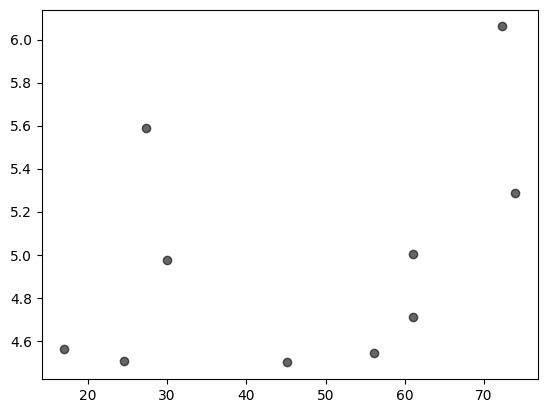

In [8]:
plot_scatter(X_train)
plt.show()

In [9]:
print('mean:',np.mean(X_train,axis=0))
print('std:',np.std(X_train,axis=0))

mean: [46.81541186  4.9736765 ]
std: [19.80420471  0.50308632]


# K-means algorithm
![](images/kmeans.png)
```    
    init : {‘k-means++’, ‘random’ or an ndarray} Method for initialization, defaults to ‘k-means++’:
    ‘k-means++’ : selects initial cluster centers for k-mean clustering in a smart way to speed up convergence.
    ‘random’: choose k observations (rows) at random from data for the initial centroids.
    If an ndarray is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.
```    


In [10]:
kmeans = KMeans(init='random', n_clusters=2, random_state=0, n_init=10).fit(X_train)
print(kmeans)

Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\Lin\AppData\Local\Programs\Python\Python313\Lib\threading.py", line 1043, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "C:\Users\Lin\AppData\Local\Programs\Python\Python313\Lib\threading.py", line 994, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Lin\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1615, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
UnicodeDecodeError: 'cp950' codec can't decode byte 0xe6 in position 18: illegal multibyte sequence


KMeans(init='random', n_clusters=2, n_init=10, random_state=0)


C:\Users\Lin\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Lin\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


In [11]:
kmeans.predict([[80, 0], [100, 3]])

array([1, 1], dtype=int32)

In [12]:
kmeans.predict([[28, 5]])

array([0], dtype=int32)

In [13]:
kmeans.predict(X_train)

array([1, 1, 1, 1, 1, 0, 0, 0, 0, 1], dtype=int32)

In [14]:
kmeans.cluster_centers_

array([[24.70146249,  4.90794025],
       [61.55804477,  5.01750067]])

In [15]:
X_train

array([[72.23866396,  6.06099661],
       [60.99660317,  4.70995394],
       [60.97957342,  5.00212012],
       [73.92044753,  5.28836022],
       [56.12501941,  4.54477361],
       [24.51904689,  4.50572225],
       [29.97504101,  4.97536821],
       [27.29139912,  5.59020907],
       [17.02036293,  4.56046145],
       [45.08796113,  4.49879951]])

In [16]:
kmeans.labels_

array([1, 1, 1, 1, 1, 0, 0, 0, 0, 1], dtype=int32)

##    Plot Scatter
    1. 將資料點繪製成scatter圖. 請依據K-means分群後的結果來給予不同cluster有不同的顏色
       (cluster數非固定值)
    2. 將K-means中心點資料點也繪製上去並有較大圖樣

In [17]:
kmeans.predict(X_train)

array([1, 1, 1, 1, 1, 0, 0, 0, 0, 1], dtype=int32)

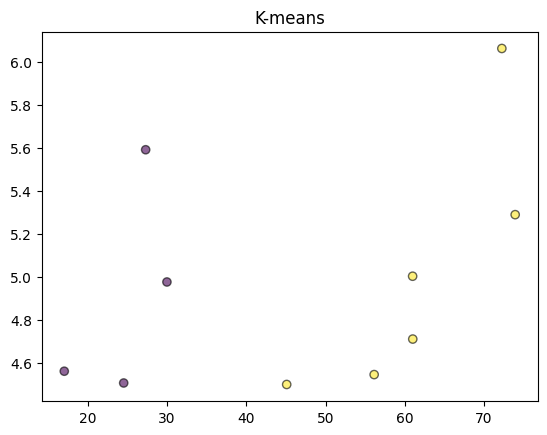

In [18]:
plot_scatter(X_train,kmeans.predict(X_train))
plt.title("K-means")
plt.show()

In [19]:
kmeans.cluster_centers_

array([[24.70146249,  4.90794025],
       [61.55804477,  5.01750067]])

In [20]:
kmeans.cluster_centers_[:,1]

array([4.90794025, 5.01750067])

In [21]:
kmeans.predict(X_train)

array([1, 1, 1, 1, 1, 0, 0, 0, 0, 1], dtype=int32)

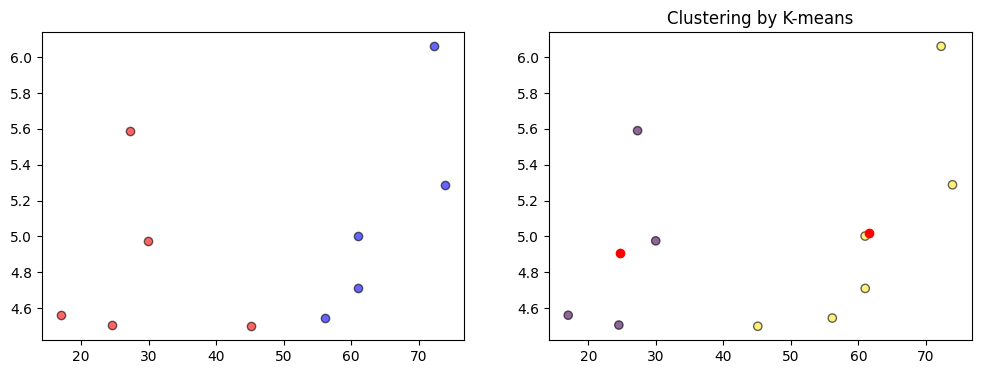

In [22]:
plt.figure(figsize=(12, 4))
plt.subplot(121)
plot_scatter(C1,color='b')
plot_scatter(C2,color='r')
plt.subplot(122)
plot_scatter(X_train,color=kmeans.predict(X_train))
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],c='red')
plt.title("Clustering by K-means")
plt.show()


## Agglomerative algorithm
    1) linkage : {“ward”, “complete”, “average”, “single”}, optional (default=”ward”)
    
    2.) affinity : string or callable, default: “euclidean”
    Metric used to compute the linkage. Can be “euclidean”, “l1”, “l2”, “manhattan”, “cosine”, or “precomputed”. If linkage is “ward”, only “euclidean” is accepted. If “precomputed”, a distance matrix (instead of a similarity matrix) is needed as input for the fit method.

In [23]:
from sklearn.cluster import AgglomerativeClustering
import numpy as np

In [24]:
acv = AgglomerativeClustering(n_clusters=2, linkage='single').fit(X_train)
print(acv)

AgglomerativeClustering(linkage='single')


In [25]:
cluster_labels=acv.fit_predict(X_train)
cluster_labels

array([0, 0, 0, 0, 0, 1, 1, 1, 1, 0])

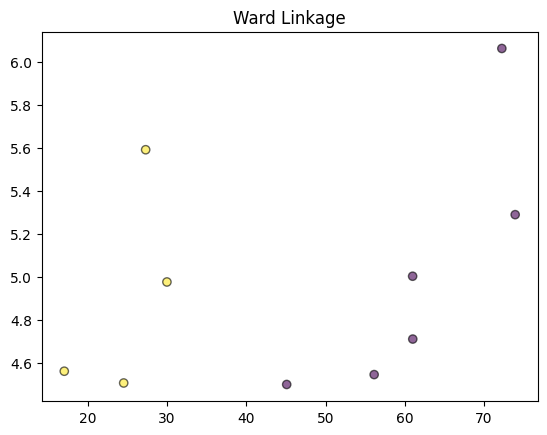

In [26]:
plot_scatter(X_train, acv.fit_predict(X_train))
plt.title("Ward Linkage")
plt.show()

In [27]:
X_train

array([[72.23866396,  6.06099661],
       [60.99660317,  4.70995394],
       [60.97957342,  5.00212012],
       [73.92044753,  5.28836022],
       [56.12501941,  4.54477361],
       [24.51904689,  4.50572225],
       [29.97504101,  4.97536821],
       [27.29139912,  5.59020907],
       [17.02036293,  4.56046145],
       [45.08796113,  4.49879951]])

## distance matrix

In [28]:
from sklearn.metrics import pairwise_distances
from sklearn.datasets import make_circles,make_blobs
D = np.round(pairwise_distances(X_train),1) 
D

array([[ 0. , 11.3, 11.3,  1.9, 16.2, 47.7, 42.3, 44.9, 55.2, 27.2],
       [11.3,  0. ,  0.3, 12.9,  4.9, 36.5, 31. , 33.7, 44. , 15.9],
       [11.3,  0.3,  0. , 12.9,  4.9, 36.5, 31. , 33.7, 44. , 15.9],
       [ 1.9, 12.9, 12.9,  0. , 17.8, 49.4, 43.9, 46.6, 56.9, 28.8],
       [16.2,  4.9,  4.9, 17.8,  0. , 31.6, 26.2, 28.9, 39.1, 11. ],
       [47.7, 36.5, 36.5, 49.4, 31.6,  0. ,  5.5,  3. ,  7.5, 20.6],
       [42.3, 31. , 31. , 43.9, 26.2,  5.5,  0. ,  2.8, 13. , 15.1],
       [44.9, 33.7, 33.7, 46.6, 28.9,  3. ,  2.8,  0. , 10.3, 17.8],
       [55.2, 44. , 44. , 56.9, 39.1,  7.5, 13. , 10.3,  0. , 28.1],
       [27.2, 15.9, 15.9, 28.8, 11. , 20.6, 15.1, 17.8, 28.1,  0. ]])

In [29]:
D.shape[0]

10

In [30]:
def min_dist(D):
    minimum=10000  
    min_x=0
    min_y=0
    for i in range(D.shape[0]):
        for j in range(i):           
            if D[i][j]<minimum:         
                minimum=D[i][j]
                min_x=i
                min_y=j
                #print(i,j,D[i][j])
                
    return (min_x,min_y),minimum

In [31]:
min_dist(D)

((2, 1), np.float64(0.3))

## plot dendrogram (樹狀圖)

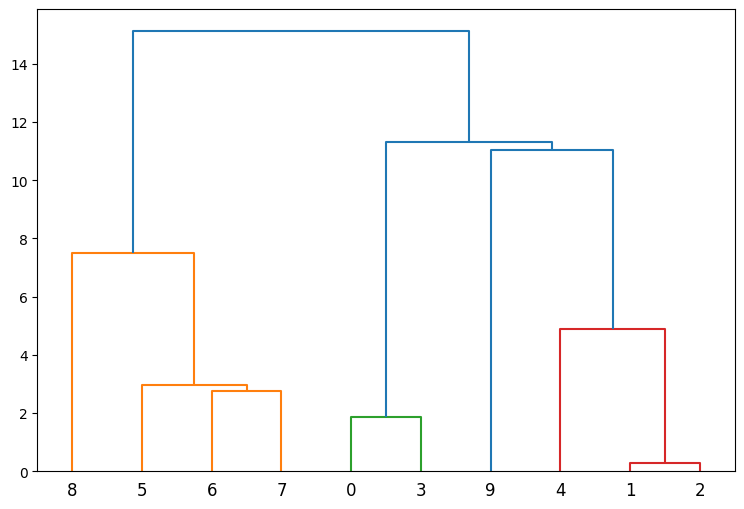

In [32]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 6))

def plot_dendrogram(x, method='ward'):
    Z = linkage(x, method)
    dendrogram(Z)

plot_dendrogram(X_train,'single')
plt.show()

## Comparing different hierarchical linkage methods

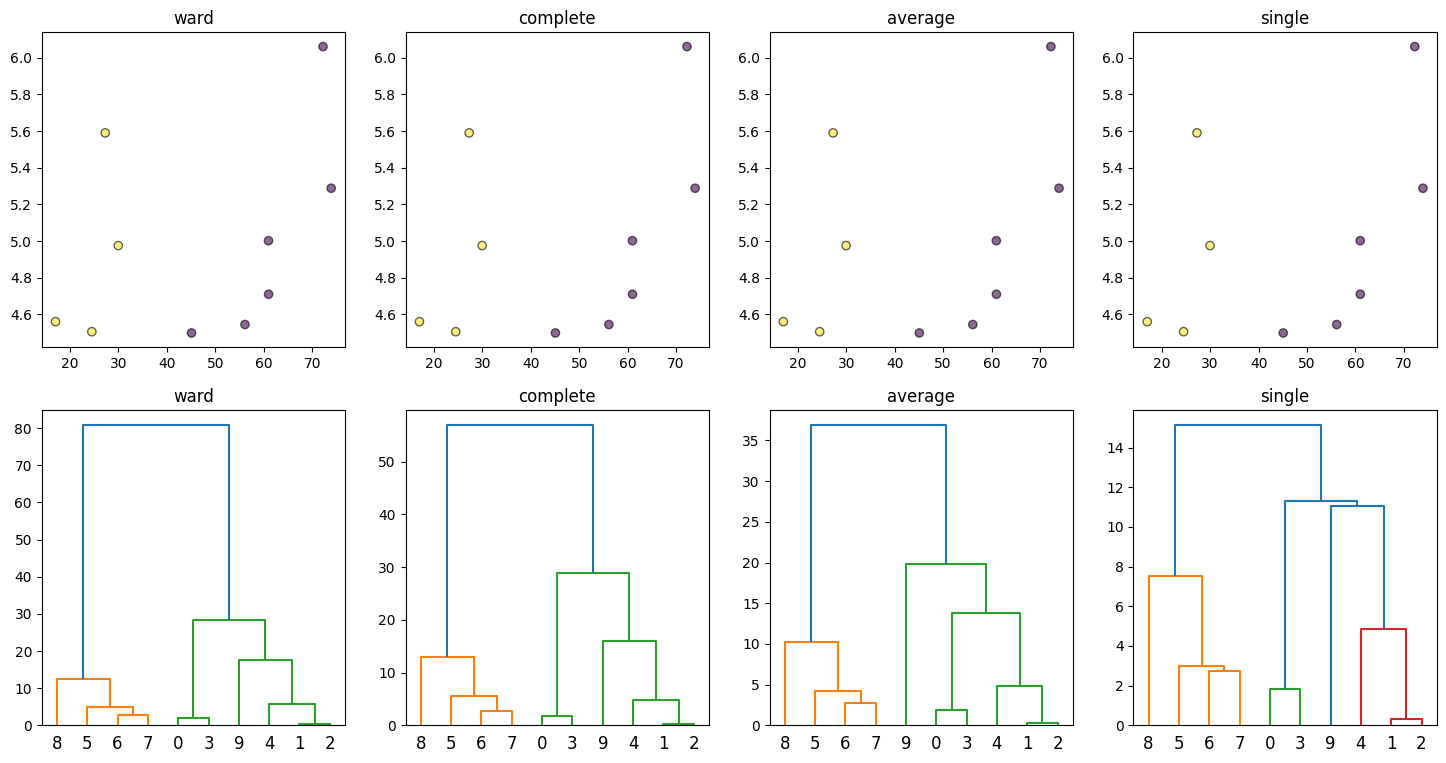

In [33]:

def compare_linkage(X):
    
    plt.figure(figsize=(18, 9))
    linktype=['ward', 'complete', 'average', 'single']

    for i,link in enumerate(linktype):
        model = AgglomerativeClustering(n_clusters=2,linkage=link).fit(X)
        cluster_labels=model.fit_predict(X)   
        #plot scatter 
        plt.subplot(2,4,i+1)        
        plot_scatter(X, cluster_labels)
        plt.title(link)
        # plot dendrogram
        plt.subplot(2,4,i+5)        
        plot_dendrogram(X,link)
        plt.title(link)   

    plt.show()     
    
compare_linkage(X_train)

## Apply K-means with re-scaled data
### Feature Re-scale 

In [34]:
X_train

array([[72.23866396,  6.06099661],
       [60.99660317,  4.70995394],
       [60.97957342,  5.00212012],
       [73.92044753,  5.28836022],
       [56.12501941,  4.54477361],
       [24.51904689,  4.50572225],
       [29.97504101,  4.97536821],
       [27.29139912,  5.59020907],
       [17.02036293,  4.56046145],
       [45.08796113,  4.49879951]])

[46.81541186  4.9736765 ]
[19.80420471  0.50308632]


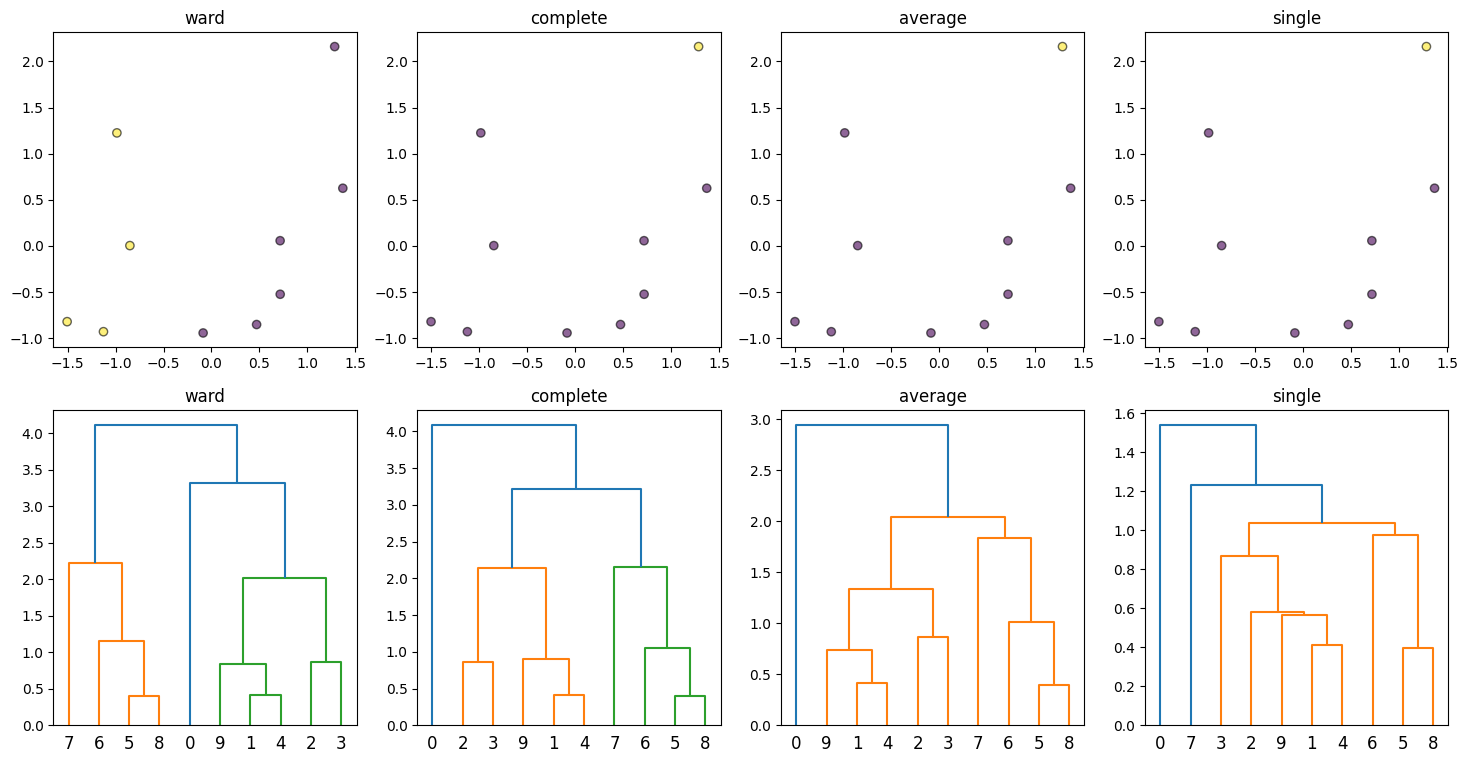

In [35]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler().fit(X_train)  #Compute the statistics to be used for later scaling.
print(sc.mean_)  #mean
print(sc.scale_) #standard deviation

#transform: (x-u)/std.
X_train_std = sc.transform(X_train)

np.round(np.mean(X_train_std,axis=0),2)

compare_linkage(X_train_std)

In [36]:
from sklearn.datasets import make_circles
# make a synthetic dataset (circle) #array of shape [n_samples, 2]
X, y = make_circles(n_samples=100, shuffle=True,factor=0.5, random_state=0, noise=0.05) 

In [37]:
print(X[:10])
print(y[:10])

[[-0.97084503 -0.12673179]
 [-0.01989117 -0.45880462]
 [ 0.95036645  0.21475102]
 [ 0.3868271   0.25685525]
 [-0.53375109 -0.00663921]
 [ 0.34970205 -0.2956982 ]
 [-0.41722927  0.81854348]
 [-0.47625865  0.08139568]
 [ 0.42783229  0.26529816]
 [ 0.36259195 -0.27483444]]
[0 1 0 1 1 1 0 1 1 1]


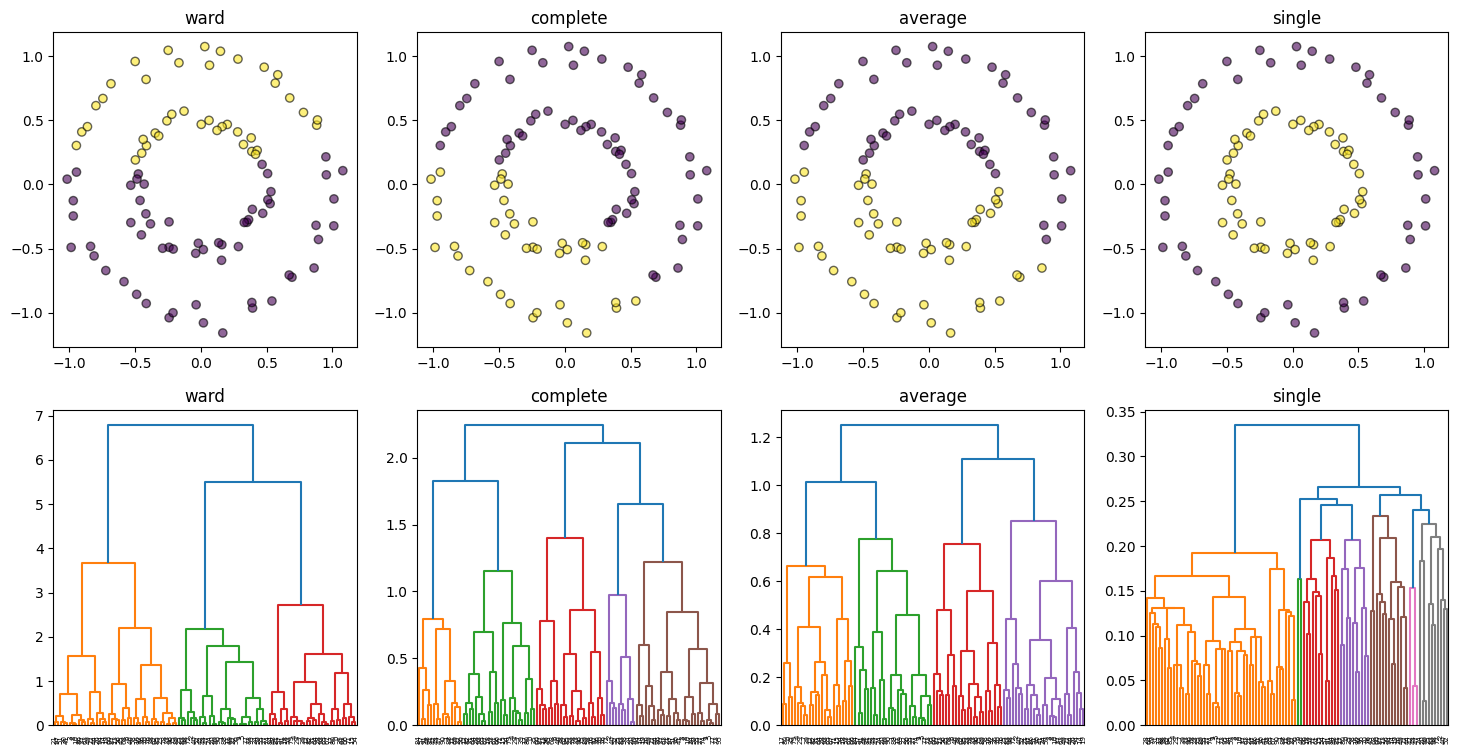

In [38]:
compare_linkage(X)

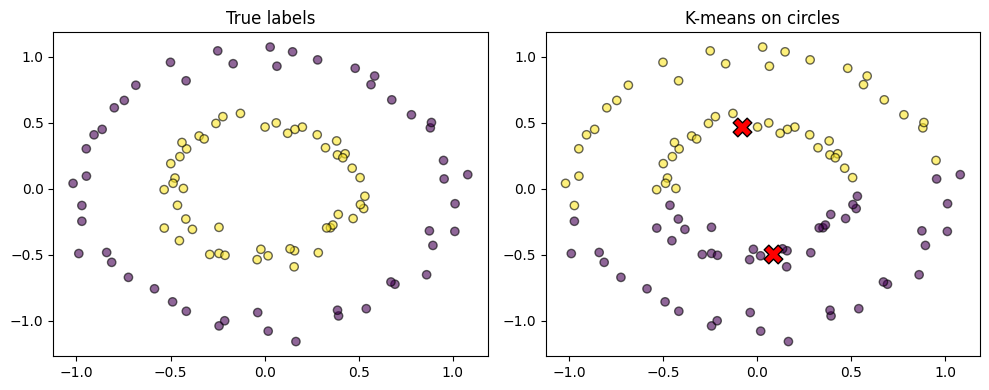

In [39]:
kmeans_circle = KMeans(n_clusters=2, random_state=0, n_init=10).fit(X)

plt.figure(figsize=(10, 4))
plt.subplot(121)
plot_scatter(X, color=y)
plt.title('True labels')

plt.subplot(122)
plot_scatter(X, color=kmeans_circle.labels_)
plt.scatter(kmeans_circle.cluster_centers_[:, 0],
            kmeans_circle.cluster_centers_[:, 1],
            c='red', s=180, marker='X', edgecolor='k')
plt.title('K-means on circles')

plt.tight_layout()
plt.show()